In [2201]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [2202]:
#csv_path="fraud_dataset.csv"
csv_path="fraud_dataset.csv"
df=pd.read_csv(csv_path)


In [2203]:
#Replace whitespaces, mutilple hypens etc with one single whitespace.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)


In [2204]:
#Checking number of rows and columns.
print(f"{df.shape}")


(5000, 13)


In [2205]:
df.dtypes


transaction_id          str
customer_id             str
amount              float64
customer_age        float64
past_fraud_count      int64
avg_spend           float64
is_international      int64
device_type             str
customer_region         str
category                str
merchant                str
transaction_time        str
is_fraud              int64
dtype: object

In [2206]:
#Checking overall columns data.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    5000 non-null   str    
 1   customer_id       5000 non-null   str    
 2   amount            5000 non-null   float64
 3   customer_age      4500 non-null   float64
 4   past_fraud_count  5000 non-null   int64  
 5   avg_spend         5000 non-null   float64
 6   is_international  5000 non-null   int64  
 7   device_type       5000 non-null   str    
 8   customer_region   5000 non-null   str    
 9   category          4500 non-null   str    
 10  merchant          4500 non-null   str    
 11  transaction_time  5000 non-null   str    
 12  is_fraud          5000 non-null   int64  
dtypes: float64(3), int64(3), str(7)
memory usage: 507.9 KB


In [2207]:
#Checking how the data is distributed in all numerical columns
df.describe()


,amount,customer_age,past_fraud_count,avg_spend,is_international,is_fraud
count,5000.000000,4500.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,191.972524,43.141778,0.200600,100.872632,0.15640,0.010800
std,960.205272,14.919474,0.442718,50.436836,0.36327,0.103371
min,0.000000,18.000000,0.000000,-81.760000,0.00000,0.000000
25%,28.717500,30.000000,0.000000,67.147500,0.00000,0.000000
50%,70.865000,43.000000,0.000000,100.900000,0.00000,0.000000
75%,143.140000,56.000000,0.000000,134.575000,0.00000,0.000000
max,27166.000000,69.000000,3.000000,323.950000,1.00000,1.000000


In [2208]:
#Checking the top 5 rows
df.head()


,transaction_id,customer_id,amount,customer_age,past_fraud_count,avg_spend,is_international,device_type,customer_region,category,merchant,transaction_time,is_fraud
0,T1000,C291,46.93,68.0,0,124.55,1,mobile,North,travel,Walmart,01/01/2024 08:10,0
1,T1001,C280,301.01,57.0,1,116.49,0,pos,North,travel,NaN,2024-01-01 07:50:12,0
2,T1002,C321,131.67,NaN,1,96.91,0,web,North,grocery,Amazon,2024-01-01 18:09:06,0
3,T1003,C450,91.29,49.0,0,108.17,0,pos,West,electronics,NaN,2024/01/01 03:52,0
4,T1004,C111,16.96,65.0,0,70.14,0,pos,South,grocery,Amazon,Jan 01 2024 09:08,0


In [2209]:
#Checking sum of null values in each column
df.isna().sum()


transaction_id        0
customer_id           0
amount                0
customer_age        500
past_fraud_count      0
avg_spend             0
is_international      0
device_type           0
customer_region       0
category            500
merchant            500
transaction_time      0
is_fraud              0
dtype: int64

In [2210]:
#Check percentage of missing values in each column.
missing_perc=((df.isnull().sum() / len(df)) * 100)
missing_perc[missing_perc>0]


customer_age    10.0
category        10.0
merchant        10.0
dtype: float64

In [2211]:
df["transaction_time"].info()
print("\n------------------------------------------------------------------------------------------\n")

#Fix the datetime format.
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='mixed', dayfirst=True , errors='coerce')
df["transaction_time"].info()


<class 'pandas.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: transaction_time
Non-Null Count  Dtype
--------------  -----
5000 non-null   str  
dtypes: str(1)
memory usage: 39.2 KB

------------------------------------------------------------------------------------------

<class 'pandas.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: transaction_time
Non-Null Count  Dtype         
--------------  -----         
5000 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 39.2 KB


In [2212]:
#handling missing values.
df['customer_age']=df['customer_age'].fillna(df['customer_age'].median())

#Replaced missing values in category and merchant columns with "Unknown" str 
#cause there were 500 missing values in both columns 
#with the mode in both been closest to the second largest value 
#so giving it the value "Unknown" seems better than some very specific values and creating bias.
df['category']=df['category'].fillna("Unknown")
df['merchant']=df['merchant'].fillna("Unknown")


In [2213]:
#Checking if there are any missing values left even after replacing.
df.isna().sum()


transaction_id      0
customer_id         0
amount              0
customer_age        0
past_fraud_count    0
avg_spend           0
is_international    0
device_type         0
customer_region     0
category            0
merchant            0
transaction_time    0
is_fraud            0
dtype: int64

In [2214]:
outliers_columns=df.select_dtypes(include='number').drop(columns=['transaction_id','customer_id','is_fraud','is_international'], errors='ignore').columns
outliers_columns


Index(['amount', 'customer_age', 'past_fraud_count', 'avg_spend'], dtype='str')

In [2215]:
total_outliers=0
for column in outliers_columns:
#Dectecting outliers using basic Interquartile Range Method in the amount column.
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]
    if(len(outliers)>=1):
        print(f"Column: '{column}', Outliers: '{len(outliers)}'")
        print(f"Exporting {column} Outliers to CSV..............")
        #outliers.to_csv(f"/kaggle/working/{column}_outliers.csv")
        outliers.to_csv(f"{column}_outliers.csv")
        print(f"{column} outliers to csv done.")
        print(f"----------------------------------------------------------------------------------------------\n")
        total_outliers+=len(outliers)
print(f"Total Outliers: '{total_outliers}'")


Column: 'amount', Outliers: '301'
Exporting amount Outliers to CSV..............
amount outliers to csv done.
----------------------------------------------------------------------------------------------

Column: 'past_fraud_count', Outliers: '918'
Exporting past_fraud_count Outliers to CSV..............
past_fraud_count outliers to csv done.
----------------------------------------------------------------------------------------------

Column: 'avg_spend', Outliers: '46'
Exporting avg_spend Outliers to CSV..............
avg_spend outliers to csv done.
----------------------------------------------------------------------------------------------

Total Outliers: '1265'


In [2216]:
print(total_outliers)


1265


In [2217]:
categorical_cols=['device_type','customer_region','category','merchant']


In [2218]:
for column in categorical_cols:
    df[column] = df[column].str.strip().str.lower()


In [2219]:
for column in categorical_cols:
    print(f"\nColumn: {column}")
    print(f"Number of unique values: {df[column].nunique()}")
    print("Unique values:")
    print(df[column].unique())
    print(f"\nColumn: {column}")
    print(df[column].value_counts())



Column: device_type
Number of unique values: 3
Unique values:
<StringArray>
['mobile', 'pos', 'web']
Length: 3, dtype: str

Column: device_type
device_type
web       1684
pos       1674
mobile    1642
Name: count, dtype: int64

Column: customer_region
Number of unique values: 4
Unique values:
<StringArray>
['north', 'west', 'south', 'east']
Length: 4, dtype: str

Column: customer_region
customer_region
south    1277
east     1263
west     1248
north    1212
Name: count, dtype: int64

Column: category
Number of unique values: 6
Unique values:
<StringArray>
['travel', 'grocery', 'electronics', 'shopping', 'food', 'unknown']
Length: 6, dtype: str

Column: category
category
electronics    979
grocery        915
travel         878
food           867
shopping       861
unknown        500
Name: count, dtype: int64

Column: merchant
Number of unique values: 6
Unique values:
<StringArray>
['walmart', 'unknown', 'amazon', 'target', 'starbucks', 'bestbuy']
Length: 6, dtype: str

Column: merchant

In [2220]:
ohe= OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
ohe.set_output(transform="pandas")


,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [2221]:
encoded_df = ohe.fit_transform(df[categorical_cols])


In [2222]:
final_df = pd.concat(
    [df.drop(columns=categorical_cols), encoded_df],
    axis=1
)


In [2223]:
final_df.dtypes


transaction_id                      str
customer_id                         str
amount                          float64
customer_age                    float64
past_fraud_count                  int64
avg_spend                       float64
is_international                  int64
transaction_time         datetime64[us]
is_fraud                          int64
device_type_mobile              float64
device_type_pos                 float64
device_type_web                 float64
customer_region_east            float64
customer_region_north           float64
customer_region_south           float64
customer_region_west            float64
category_electronics            float64
category_food                   float64
category_grocery                float64
category_shopping               float64
category_travel                 float64
category_unknown                float64
merchant_amazon                 float64
merchant_bestbuy                float64
merchant_starbucks              float64


In [2224]:
x = final_df.drop(columns=['transaction_id', 'customer_id', 'is_fraud', 'transaction_time'])
y=final_df['is_fraud']
print(x)


      amount  customer_age  past_fraud_count  avg_spend  is_international  \
0      46.93          68.0                 0     124.55                 1   
1     301.01          57.0                 1     116.49                 0   
2     131.67          43.0                 1      96.91                 0   
3      91.29          49.0                 0     108.17                 0   
4      16.96          65.0                 0      70.14                 0   
...      ...           ...               ...        ...               ...   
4995  227.69          39.0                 1     164.06                 0   
4996   12.71          45.0                 1     105.68                 0   
4997   39.73          56.0                 1     112.05                 0   
4998  169.14          43.0                 1      15.03                 0   
4999   90.96          21.0                 0       9.64                 0   

      device_type_mobile  device_type_pos  device_type_web  \
0            

In [2225]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,stratify=y, random_state=42)


In [2226]:
scaler=StandardScaler()
num_cols=['amount', 'customer_age','avg_spend','past_fraud_count']
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_test[num_cols]=scaler.transform(x_test[num_cols])


In [2227]:
from sklearn.model_selection import GridSearchCV
params= {'C':[0.01,0.1,1,10,100]}
grid = GridSearchCV(LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000),params,cv=5,scoring='f1')
grid.fit(x_train,y_train)
print(grid.best_params_)
print(grid.best_score_)
#lrm=LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000)
#lrm.fit(x_train,y_train)


{'C': 100}
0.3801437908496732


In [ ]:
lrm = grid.best_estimator_

lrm.fit(x_train, y_train)

y_pred = lrm.predict(x_test)


In [2229]:
print(y_train.value_counts())


is_fraud
0    3957
1      43
Name: count, dtype: int64


In [2230]:
#y_pred=lrm.predict(x_test)
accu=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
print("Accuracy :", accu)

print("\nConfusion Matrix")
print(cm)


Accuracy : 0.964

Confusion Matrix
[[957  32]
 [  4   7]]


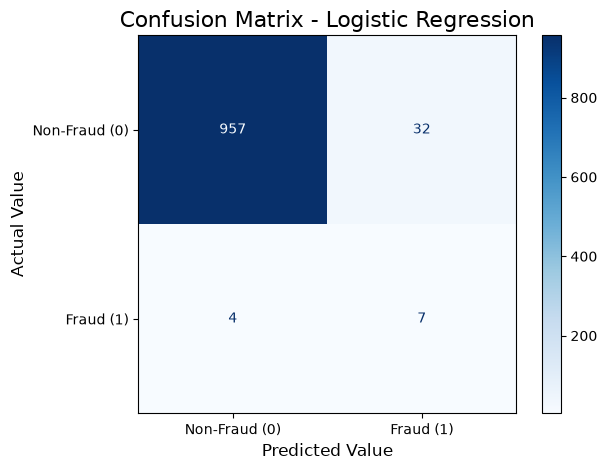

In [2231]:
from sklearn.metrics import ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay.from_estimator(lrm,x_test,y_test,display_labels=["Non-Fraud (0)", "Fraud (1)"], values_format='d', cmap='Blues')
disp.ax_.set_title("Confusion Matrix - Logistic Regression", fontsize=16)
disp.ax_.set_xlabel("Predicted Value", fontsize=12)
disp.ax_.set_ylabel("Actual Value", fontsize=12)
plt.tight_layout()
plt.show()


In [2232]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))



Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       989
           1       0.18      0.64      0.28        11

    accuracy                           0.96      1000
   macro avg       0.59      0.80      0.63      1000
weighted avg       0.99      0.96      0.97      1000



In [2233]:
fp = df.loc[x_test.index[(y_test == 0) & (y_pred == 1)]]
print("False Positive Records:")
print(len(fp))
display(fp)
fn = df.loc[x_test.index[(y_test == 1) & (y_pred == 0)]]
print("False Negative Records:")
print(len(fn))
display(fn)


False Positive Records:
32


,transaction_id,customer_id,amount,customer_age,past_fraud_count,avg_spend,is_international,device_type,customer_region,category,merchant,transaction_time,is_fraud
1897,T2897,C351,20.83,25.0,2,27.01,0,mobile,east,travel,starbucks,2024-01-01 18:07:43,0
4543,T5543,C291,33.31,43.0,1,98.07,1,pos,east,electronics,bestbuy,2024-01-01 22:18:16,0
4321,T5321,C277,274.79,43.0,2,138.35,1,web,south,electronics,target,2024-01-01 19:07:00,0
2844,T3844,C260,86.07,45.0,1,110.39,1,pos,north,food,unknown,2024-01-01 09:19:00,0
343,T1343,C441,56.89,31.0,2,97.16,0,pos,east,grocery,amazon,2024-01-02 01:45:00,0
4945,T5945,C305,14150.50,54.0,1,156.11,1,mobile,north,travel,starbucks,2024-01-01 09:25:00,0
613,T1613,C415,8.53,38.0,1,177.49,1,pos,west,unknown,target,2024-01-01 12:14:00,0
4933,T5933,C225,58.85,27.0,1,87.83,1,web,north,travel,unknown,2024-01-01 19:45:00,0
3620,T4620,C179,111.71,43.0,1,35.79,1,mobile,west,travel,amazon,2024-01-01 23:57:00,0
1585,T2585,C448,14.67,44.0,2,117.82,0,mobile,east,travel,starbucks,2024-01-01 22:48:00,0


False Negative Records:
4


,transaction_id,customer_id,amount,customer_age,past_fraud_count,avg_spend,is_international,device_type,customer_region,category,merchant,transaction_time,is_fraud
2132,T3132,C218,82.04,66.0,1,144.91,1,mobile,east,shopping,walmart,2024-01-01 22:39:33,1
11,T1011,C137,350.36,65.0,1,50.43,1,mobile,south,food,walmart,2024-01-01 03:52:00,1
3250,T4250,C470,3802.00,62.0,1,173.21,0,web,west,shopping,walmart,2024-01-01 07:34:00,1
1633,T2633,C387,7934.50,42.0,1,97.41,0,mobile,east,grocery,walmart,2024-01-01 11:28:00,1


In [2234]:
fp.to_csv("false_positives.csv", index=False)
print("False Positive file saved successfully.")
fn.to_csv("false_negatives.csv", index=False)
print("False Negative file saved successfully.")


False Positive file saved successfully.
False Negative file saved successfully.


In [2235]:
print(fp['merchant'].value_counts())
print(f"----------------------------------------------------------------------------------------------\n")
print(fp['category'].value_counts())
print(f"----------------------------------------------------------------------------------------------\n")
print(fp['device_type'].value_counts())
print(f"----------------------------------------------------------------------------------------------\n")
print(fn['merchant'].value_counts())
print(f"----------------------------------------------------------------------------------------------\n")
print(fn['category'].value_counts())
print(f"----------------------------------------------------------------------------------------------\n")
print(fn['device_type'].value_counts())
print(f"----------------------------------------------------------------------------------------------\n")


merchant
amazon       9
starbucks    8
bestbuy      7
target       6
unknown      2
Name: count, dtype: int64
----------------------------------------------------------------------------------------------

category
travel         16
electronics     5
food            4
unknown         3
grocery         2
shopping        2
Name: count, dtype: int64
----------------------------------------------------------------------------------------------

device_type
pos       13
web       10
mobile     9
Name: count, dtype: int64
----------------------------------------------------------------------------------------------

merchant
walmart    4
Name: count, dtype: int64
----------------------------------------------------------------------------------------------

category
shopping    2
food        1
grocery     1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------

device_type
mobile    3
web       1
Name: count, dtype: int64
---

In [2236]:
csv=pd.read_csv("false_negatives.csv")
csv.head()


,transaction_id,customer_id,amount,customer_age,past_fraud_count,avg_spend,is_international,device_type,customer_region,category,merchant,transaction_time,is_fraud
0,T3132,C218,82.04,66.0,1,144.91,1,mobile,east,shopping,walmart,2024-01-01 22:39:33,1
1,T1011,C137,350.36,65.0,1,50.43,1,mobile,south,food,walmart,2024-01-01 03:52:00,1
2,T4250,C470,3802.00,62.0,1,173.21,0,web,west,shopping,walmart,2024-01-01 07:34:00,1
3,T2633,C387,7934.50,42.0,1,97.41,0,mobile,east,grocery,walmart,2024-01-01 11:28:00,1


In [2237]:
fp[['amount','avg_spend','past_fraud_count']].describe()

fn[['amount','avg_spend','past_fraud_count']].describe()


,amount,avg_spend,past_fraud_count
count,4.000000,4.000000,4.0
mean,3042.225000,116.490000,1.0
std,3675.161907,54.014889,0.0
min,82.040000,50.430000,1.0
25%,283.280000,85.665000,1.0
50%,2076.180000,121.160000,1.0
75%,4835.125000,151.985000,1.0
max,7934.500000,173.210000,1.0


In [2238]:
print(f"========== DATA ANALYSIS REVIEW ==========\n")

print(f"Total Number of Records: {len(df)}\n")

print(f"Total Number of Columns: {len(df.columns)}\n")

print(f"Fraud Records:")
print(f"{df["is_fraud"].value_counts()}\n")

print(f"Percentage of Fraud and Non-Fraud:")
print(f"{df["is_fraud"].value_counts(normalize=True) * 100}\n")

print("Missing Values After Cleaning:")
print(f"{df.isnull().sum()}\n")

print(f"Outliers Found: {len(outliers)}\n")

print(f"Model Accuracy: {accu}\n")

print(f"Confusion Matrix:")
print(f"{cm}")


========== DATA ANALYSIS REVIEW ==========

Total Number of Records: 5000

Total Number of Columns: 13

Fraud Records:
is_fraud
0    4946
1      54
Name: count, dtype: int64

Percentage of Fraud and Non-Fraud:
is_fraud
0    98.92
1     1.08
Name: proportion, dtype: float64

Missing Values After Cleaning:
transaction_id      0
customer_id         0
amount              0
customer_age        0
past_fraud_count    0
avg_spend           0
is_international    0
device_type         0
customer_region     0
category            0
merchant            0
transaction_time    0
is_fraud            0
dtype: int64

Outliers Found: 46

Model Accuracy: 0.964

Confusion Matrix:
[[957  32]
 [  4   7]]
